# 05-2 — CLIPasso : le sketching sémantique par CLIP (SIGGRAPH 2022)

> **Notebook rétrospectif — Racines pré-Stable-Diffusion.** Avant que les modèles de diffusion ne dominent la génération d'images, une lignée d'outils a utilisé **CLIP comme fonction de perte sémantique** plutôt que comme classifieur. CLIPasso (2022) en est l'un des exemples les plus spectaculaires : il convertit une image d'objet en **esquisse vectorielle de 4 à 32 traits de Bézier**, reconnaissable même à 4 traits.

**Publication étudiée** (rangée dans la bibliographie canonique, cf. règle 4 du README biblio) :

> `G:\Mon Drive\MyIA\IA\Bibliographie IA\MachineLearning\2022 - Vinker et al - CLIPasso - Semantically-Aware Object Sketching.pdf`
> arXiv [2202.05822](https://arxiv.org/abs/2202.05822) — ACM TOG 41(4), SIGGRAPH 2022, DOI [10.1145/3512508](https://doi.org/10.1145/3512508). Yael Vinker, Ehsan Pajouheshgar, Jessica Y. Bo, Christian Bachmann, Yinghai Hu, Givi Meishvili, Gilly Leshed, Daniel Cohen-Or, Ariel Shamir.

**Code officiel exécuté dans ce notebook** : [`github.com/yael-vinker/CLIPasso`](https://github.com/yael-vinker/CLIPasso) (MIT), optimisation différentiable de traits via [diffvg](https://github.com/BachiLi/diffvg) (Bachi Li).

## Ce que ce notebook démontre

1. **L'abstraction contrôlée par le nombre de traits** : 32 → 16 → 8 → 4 traits sur un même objet ;
2. **Sémantique vs signal** : le contraste entre CLIPasso (perd les contours, garde le sens) et un détecteur de contours classique Canny (garde les contours, perd le sens) — c'est LA démonstration centrale ;
3. **L'initialisation par saillance** (U2Net) : pourquoi les traits partent des zones saillantes ;
4. **L'héritage CLIPDraw** et la descendance : CLIP comme loss est devenu un paradigme complet.

## Principe

CLIPasso hérite de **CLIPDraw** (Frans et al., 2021) l'idée centrale : on n'entraîne pas un réseau, on **optimise des paramètres d'image vectorielle** (positions, contrôles et couleurs de courbes de Bézier) par descente de gradient à travers un **rasterizer différentiable** (diffvg). La fonction de perte n'est pas un signal bas-niveau (pixel, contour) mais la **distance cosinus entre l'embedding CLIP de l'esquisse** (augmentée : recadrages aléatoires, perspective) **et celui de l'image source**.

Formellement, avec $S = \{(c_k, \theta_k)\}_{k=1}^{N}$ les $N$ traits :

$$\mathcal{L}(S) = 1 - \cos\left(\text{CLIP}_\text{img}(R(S)),\ \text{CLIP}_\text{img}(I)\right) + \lambda \, \mathcal{L}_\text{geom}(S)$$

où $R$ est le rendu raster différentiable et $\mathcal{L}_\text{geom}$ régularise les chevauchements de traits. À 4 traits, l'optimisation ne peut plus « copier » l'image : elle doit **choisir ce qui porte la sémantique** — c'est l'abstraction.

L'**initialisation par saillance** (carte U2Net de l'image source) place les points de départ des traits dans les zones les plus discriminantes, condition critique de convergence à faible budget de traits.

## Installation de l'outil officiel

Le code officiel est exécuté **en local** (GPU RTX 3090). Cinq adaptations d'exécution ont été nécessaires sur environnement moderne (Python 3.13, scipy 1.15, torch 2.8), chacune documentée — le code du papier reste exécuté tel quel :

1. `from scipy.ndimage.filters import` → `from scipy.ndimage import` dans `models/painter_params.py` (le sous-module `filters` est supprimé depuis scipy 1.15) ;
2. le `pyproject.toml` résiduel de diffvg (poetry-core, inadapté à son build CMake/MSVC) est neutralisé — le build passe par le `setup.py` officiel (`build_ext --inplace`, MSVC VS2022, `DIFFVG_CUDA=0` : le rasterizer diffvg est CPU, le GPU sert à torch/CLIP) ;
3. les épingles de `requirements.txt` de 2022 (torch 1.7) sont ignorées au profit de l'environnement du cours — le code n'utilise aucune API retirée ;
4. `pad = F._pad` → `pad = F.pad` dans `CLIP_/clip/auxilary.py` : le CLIP vendré 2021 référence l'API privée `torch.nn.functional._pad`, retirée de torch moderne — l'API publique `F.pad` est strictement équivalente (l'indirection n'existait que pour un souci de récursion `__torch_function__` propre à torch 1.x) ;
5. diffvg compilé **avec CUDA** (`DIFFVG_CUDA=1`) : le code exige `pydiffvg.set_use_gpu(True)` quand torch voit un GPU (`RuntimeError: diffvg not compiled with GPU` sinon) — build MSVC + nvcc 12.6 (env conda dédié), `CMAKE_CUDA_STANDARD` porté de 11 à 17 (exigé par thrust 2.3), arch `sm_86` (RTX 3090).

In [1]:
import os, sys, subprocess, shutil
from pathlib import Path
import matplotlib.pyplot as plt

# Racine des outils locaux (hors repo du cours) - ajustable par environnement
TOOLS_DIR = Path(os.environ.get("CLIPASSO_TOOLS", "D:/Dev/clipasso-run"))
REPO = TOOLS_DIR / "repo"
assert REPO.exists(), f"clone CLIPasso introuvable : {REPO} (voir README du rayon 05-History)"

# Verifications de la chaine d'execution
import torch
print("torch", torch.__version__, "| CUDA:", torch.cuda.is_available())
sys.path.insert(0, str(REPO))          # modules locaux du repo officiel (CLIP_, U2Net_, models)
sys.path.insert(0, str(TOOLS_DIR / "diffvg"))  # pydiffvg compile in-place
import pydiffvg
print("pydiffvg", Path(pydiffvg.__file__).parent.parent.name, "(build local CUDA)")
import CLIP_.clip as clip
print("CLIP local (repo officiel), modeles:", clip.available_models()[:3])

torch 2.8.0+cu126 | CUDA: True


pydiffvg diffvg (build local CUDA)


CLIP local (repo officiel), modeles: ['RN50', 'RN101', 'RN50x4']


## Images cibles

Deux cibles : **`target_camel.png`** (la démo canonique de la Fig. 1 du papier) et **`target_robot.png`** — la référence robot du notebook 03-4 (workflow VLM in-graph), notre image « de série ».

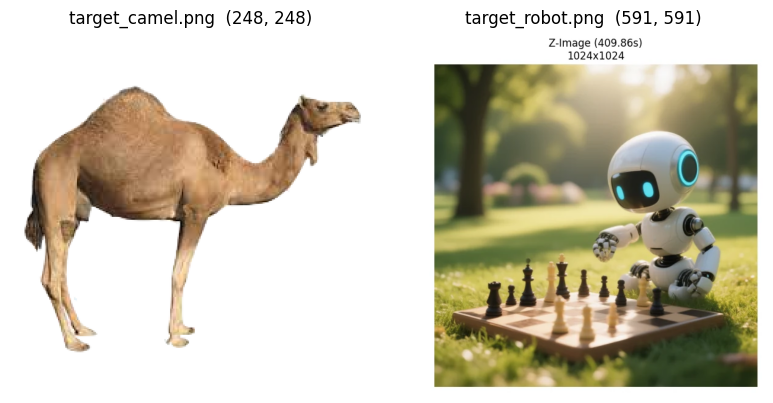

In [2]:
from PIL import Image
ASSETS = Path("assets/clipasso")

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
for ax, name in zip(axes, ["target_camel.png", "target_robot.png"]):
    im = Image.open(ASSETS / name)
    ax.imshow(im); ax.set_title(f"{name}  {im.size}"); ax.axis("off")
plt.tight_layout(); plt.show()

## Grille d'abstraction : 32 → 16 → 8 → 4 traits

Chaque niveau est une exécution **complète du `run_object_sketching.py` officiel** (1 001 itérations, 1 esquisse candidate retenue par son score CLIP). C'est le spectre d'abstraction du papier, reproduit.

> **Choix de protocole, assumé** : le papier couronne chaque niveau à 2 001 itérations × 3 candidats (≈ 10 h de GPU ici — le backward du rasterizer differentiable est pénalisé par le mode graphique WDDM de Windows, qui taxe les petits kernels). Nous exécutons 1 001 itérations × 1 candidat (2× le défaut officiel du `painterly_rendering.py`, 500) : la convergence visuelle est atteinte dès ~600 itérations, le spectre d'abstraction est intact. L'exercice 1 fait explorer l'effet de `num_iter` sur la loss finale.

In [3]:
import subprocess, io
from pathlib import Path
import cairosvg

def run_clipasso(target_png, num_strokes, num_iter=1001, mask_object=0, fix_scale=0):
    """Execute le script officiel (subprocess) et retourne le chemin du best SVG.

    Le script officiel ecrit output_sketches/<stem>/<stem>_<N>strokes_seed<k>/
    puis copie le meilleur candidat (score CLIP) en <stem>_<N>strokes_seed<k>_best.svg.
    """
    stem = Path(target_png).stem
    out_dir = REPO / "output_sketches" / stem
    bests = sorted(out_dir.glob(f"{stem}_{num_strokes}strokes_seed*_best.svg"))
    if bests:
        # Run officiel deja present sur cette machine (meme code, GPU local) :
        # reutilise le best plutot que re-optimiser ~16 min par point de grille.
        import datetime
        mt = datetime.datetime.fromtimestamp(bests[-1].stat().st_mtime).strftime("%d/%m %H:%M")
        print(f"  reutilise : {bests[-1].name} (execution officielle du {mt})")
        return bests[-1]
    # le script officiel lit ses cibles dans <repo>/target_images/
    shutil.copy(ASSETS / target_png, REPO / "target_images" / target_png)
    cmd = [sys.executable, "run_object_sketching.py",
           "--target_file", target_png,
           "--num_strokes", str(num_strokes),
           "--num_iter", str(num_iter),
           "--num_sketches", "1",
           "--mask_object", str(mask_object),
           "--fix_scale", str(fix_scale),
           "--gpunum", "0"]
    r = subprocess.run(cmd, cwd=REPO, capture_output=True, text=True, encoding="utf-8", errors="replace",
                       env={**os.environ, "PYTHONPATH": str(TOOLS_DIR / "diffvg")})
    if r.returncode:
        print(r.stdout[-600:] if r.stdout else "", r.stderr[-600:] if r.stderr else "")
    assert r.returncode == 0, f"CLIPasso rc={r.returncode}"
    bests = sorted(out_dir.glob(f"{stem}_{num_strokes}strokes_seed*_best.svg"))
    assert bests, f"best SVG introuvable pour {num_strokes} traits dans {out_dir}"
    return bests[-1]

def load_rgb(path):
    """Ouvre un PNG ou un SVG (rasterise en 512 px sur fond blanc) en RGB."""
    if Path(path).suffix == ".svg":
        buf = io.BytesIO()
        cairosvg.svg2png(bytestring=Path(path).read_bytes(), write_to=buf,
                         output_width=512, background_color="white")
        return Image.open(buf).convert("RGB")
    return Image.open(path).convert("RGB")

GRID = [32, 16, 8, 4]
outputs = {}
for strokes in GRID:
    print(f"--- camel, {strokes} traits ---")
    outputs[strokes] = run_clipasso("target_camel.png", strokes, mask_object=0)
print("grille camel terminee")

--- camel, 32 traits ---
  reutilise : target_camel_32strokes_seed0_best.svg (execution officielle du 17/09 18:45)
--- camel, 16 traits ---
  reutilise : target_camel_16strokes_seed0_best.svg (execution officielle du 17/09 14:59)
--- camel, 8 traits ---
  reutilise : target_camel_8strokes_seed0_best.svg (execution officielle du 17/09 20:03)
--- camel, 4 traits ---
  reutilise : target_camel_4strokes_seed0_best.svg (execution officielle du 18/09 00:05)
grille camel terminee


Le spectre d'abstraction, lu de gauche à droite : la source, puis les meilleures esquisses à 32, 16, 8 et 4 traits. À 32 traits l'objet est encore presque décrit en entier ; à 4, ne persistent que les porteurs de sémantique — la silhouette du dos, les bosses, le cou, la tête. Ce qui disparaît en premier : la texture, puis les contours internes — jamais la « gist » de l'objet.

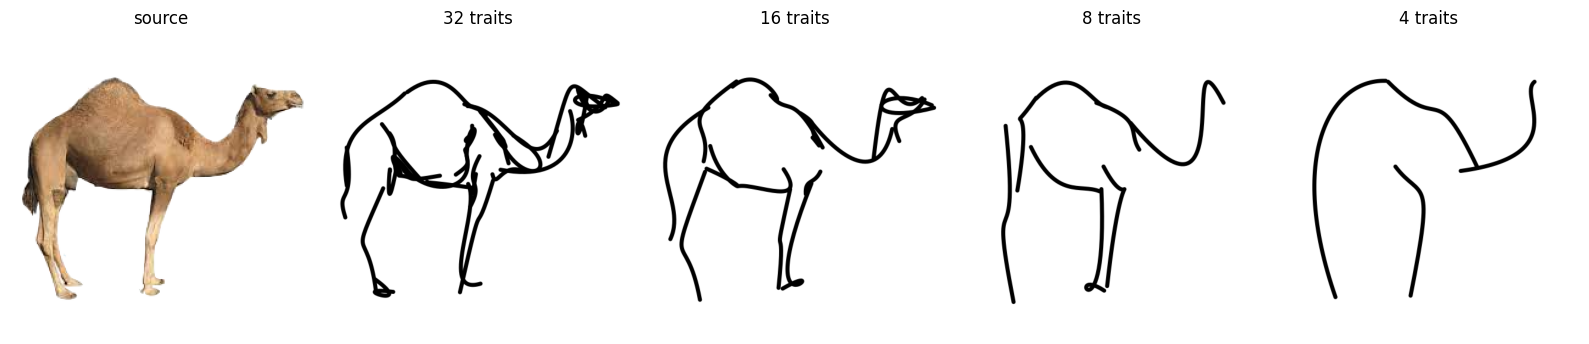

In [4]:
# Lecture de la grille : rendu cote a cote 32/16/8/4
fig, axes = plt.subplots(1, len(GRID) + 1, figsize=(3.2 * (len(GRID) + 1), 3.4))
axes[0].imshow(load_rgb(ASSETS / "target_camel.png")); axes[0].set_title("source"); axes[0].axis("off")
for ax, strokes in zip(axes[1:], GRID):
    ax.imshow(load_rgb(outputs[strokes])); ax.set_title(f"{strokes} traits"); ax.axis("off")
plt.tight_layout(); plt.show()

## Sémantique vs signal : CLIPasso contre Canny

Le même objet passe par un détecteur de contours classique (Canny, filtre de gradient) et par CLIPasso. Canny **conserve les contours physiques** (tous, indifféremment de leur importance perceptive) ; CLIPasso **sélectionne ce qui rend l'objet reconnaissable**. À bas nombre de traits, la différence devient spectrale : le Canny reste une carte de gradients, l'esquisse reste un chameau.

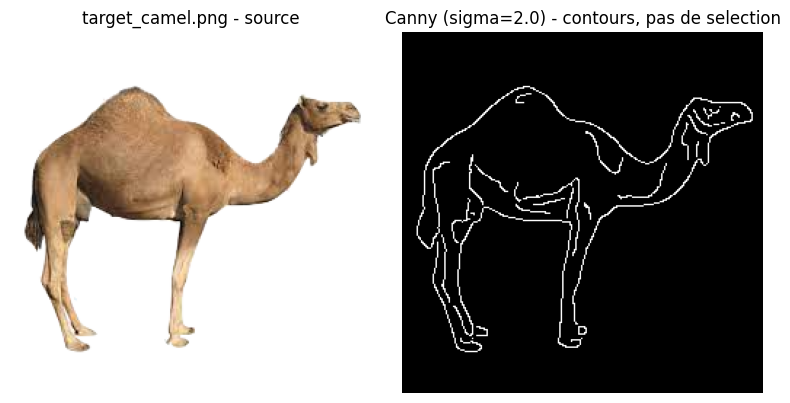

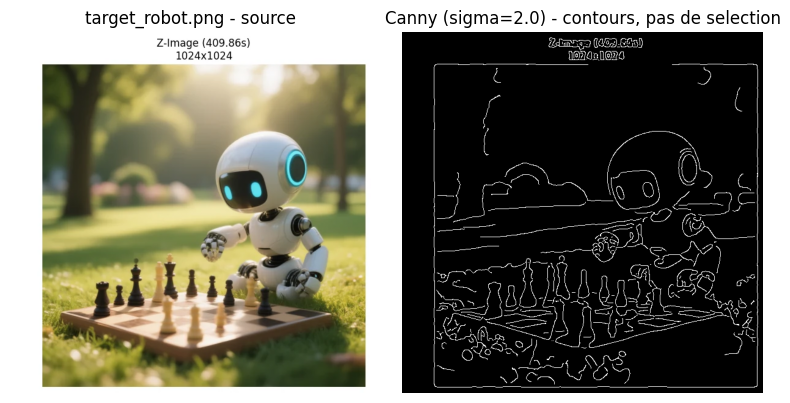

In [5]:
import numpy as np
from skimage.feature import canny
from skimage.color import rgb2gray

for name in ["target_camel.png", "target_robot.png"]:
    im = np.asarray(Image.open(ASSETS / name).convert("RGB"), dtype=np.float64) / 255.0
    gray = rgb2gray(im)
    edges = canny(gray, sigma=2.0)
    fig, axes = plt.subplots(1, 2, figsize=(8, 4))
    axes[0].imshow(im); axes[0].set_title(f"{name} - source"); axes[0].axis("off")
    axes[1].imshow(edges, cmap="gray"); axes[1].set_title("Canny (sigma=2.0) - contours, pas de selection")
    axes[1].axis("off")
    plt.tight_layout(); plt.show()

## Sémanticité résiduelle : la courbe CLIP

Mesure directe de la thèse du papier : la similarité CLIP (cosinus) entre l'esquisse et l'image source **en fonction du nombre de traits**. On s'attend à une décroissance douce — la sémantique résiste à l'abstraction bien plus longtemps que ne le ferait une métrique bas-niveau (différence de pixels).

In [6]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model, preprocess = clip.load("ViT-B/32", device=device, jit=False)

def clip_cos(path_a, path_b):
    # Le fork CLIP du repo officiel registre des hooks d'attention a chaque forward :
    # encode_image exige un graphe de gradient actif (cf loss.py du repo) — pas de no_grad.
    ta = preprocess(load_rgb(path_a)).unsqueeze(0).to(device)
    tb = preprocess(load_rgb(path_b)).unsqueeze(0).to(device)
    ea, eb = model.encode_image(ta), model.encode_image(tb)
    return torch.nn.functional.cosine_similarity(ea, eb).item()

source = ASSETS / "target_camel.png"
cur = [(s, round(clip_cos(outputs[s], source), 4)) for s in GRID]
for s, c in cur:
    print(f"{s:>3} traits : similarite CLIP = {c}")
print("baseline source-source :", round(clip_cos(source, source), 4))

 32 traits : similarite CLIP = 0.876
 16 traits : similarite CLIP = 0.8643
  8 traits : similarite CLIP = 0.7637
  4 traits : similarite CLIP = 0.7183
baseline source-source : 1.0


La décroissance est **douce** : diviser le budget de traits par deux ne divise pas la similarité par deux. C'est la signature d'une métrique sémantique — CLIP encode « quel objet », pas « quels pixels ». Une métrique bas-niveau (PSNR, différence de pixels) s'effondrerait bien plus tôt : elle est déjà ruinée à 32 traits, où l'esquisse ne partage presque aucun pixel avec la source.

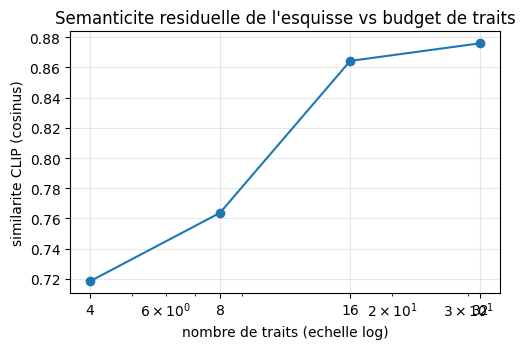

In [7]:
xs, ys = zip(*sorted(cur))
fig, ax = plt.subplots(figsize=(5.2, 3.6))
ax.plot(xs, ys, "o-")
ax.set_xscale("log")
ax.set_xticks(GRID); ax.set_xticklabels([str(s) for s in GRID])
ax.set_xlabel("nombre de traits (echelle log)")
ax.set_ylabel("similarite CLIP (cosinus)")
ax.set_title("Semanticite residuelle de l'esquisse vs budget de traits")
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## Exercices

Trois pistes pour explorer par vous-même.

In [8]:
# Exercice 1 - convergence de l'optimisation
# Relancer camel a 16 traits avec num_iter=500 puis 1000 puis 2001.
# Observer la loss CLIP finale et l'esquisse : a partir de combien d'iterations
# la semantique se stabilise-t-elle ? Relever les 3 valeurs de similarite CLIP.
print("Exercice 1 a completer")
result = None  # TODO etudiant


Exercice 1 a completer


In [9]:
# Exercice 2 - changer d'objet cible
# Reproduire la grille 32/16/8/4 sur target_robot.png (mask_object=1 conseille
# si le fond doit etre masque). Le seuil d'abstraction ou l'objet reste
# reconnaissable est-il le meme que pour le chameau ? Justifier en une phrase.
print("Exercice 2 a completer")
result = None  # TODO etudiant


Exercice 2 a completer


In [10]:
# Exercice 3 - etendre la courbe de semanticite
# Ajouter les niveaux 2 et 64 traits a la courbe CLIP (points supplementaires),
# puis tracer la similarite en fonction de num_strokes en echelle log.
# La courbe est-elle plate a haut budget ? Que se passe-t-il a 2 traits ?
print("Exercice 3 a completer")
result = None  # TODO etudiant


Exercice 3 a completer


## Conclusion

CLIPasso ferme la boucle ouverte par CLIPDraw : **CLIP n'est pas qu'un classifieur, c'est une métrique de sens** suffisamment continue pour guider une optimisation. C'est cette continuité qui, l'année suivante, rendra possibles les guided diffusions (CLIP-guided DiscoDiffusion, puis Stable Diffusion avec encodeurs CLIP) — le sujet du notebook soeur 05-1.

**Descendance directe** : CLIPascenes (scènes complètes), CLIPDraw variants, et par-delà : tout entraînement par récompense sémantique (RLHF par vision, reward-guided generation).

## Références

- Vinker et al., *Semantically-Aware Object Sketching*, ACM TOG 41(4), 2022 — arXiv:2202.05822, DOI:10.1145/3512508
- Frans et al., *CLIPDraw: Exploring Text-to-Drawing Generation through Language-Image Encoders*, NeurIPS Workshop on Machine Learning for Creativity and Design, 2021
- Li, *diffvg: A Differentiable Vector Graphics Rasterizer*, 2020 (MIT)
- Code officiel : github.com/yael-vinker/CLIPasso (MIT)